In [1]:
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

# Load everything
encoder = load_model("../data/kaggle-drdataboston/step_encoder.keras")
scaler = joblib.load("../data/kaggle-drdataboston/step_scaler.pkl")
df = pd.read_csv("../data/kaggle-drdataboston/all_5step_windows.csv")

# Drop metadata, keep only signal columns
X = df.iloc[:, 1:101].values  # Assuming column 0 is filename
X_scaled = scaler.transform(X)
X_encoded = encoder.predict(X_scaled)

print("✅ Encoded shape:", X_encoded.shape)  # e.g. (3420, 16)


2025-03-30 17:31:07.462006: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-30 17:31:07.462566: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-30 17:31:07.466055: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-30 17:31:07.476204: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743345067.488378   14866 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743345067.49

2802/2802 ━━━━━━━━━━━━━━━━━━━━ 1s 374us/step
✅ Encoded shape: (89642, 16)


In [2]:
import pandas as pd
import numpy as np
import os

base_path = '../data/kaggle-drdataboston/'
windows = pd.read_csv(os.path.join(base_path, "all_5step_windows.csv"))
matrix = pd.read_csv(os.path.join(base_path, "matrix.csv"))

meta_columns = ['Weight', 'Age', 'Height (CM)', 'gender']
file_columns = [
    'subject_left_waist_session1',
    'subject_right_pocket_session1',
    'subject_left_waist_session2',
    'subject_right_pocket_session2'
]

metadata_rows = []

for fname in windows['filename']:
    matched_row = None
    for _, row in matrix.iterrows():
        if fname in row[file_columns].values:
            matched_row = row
            break

    if matched_row is not None:
        metadata_rows.append([fname] + [matched_row[col] for col in meta_columns])
    else:
        metadata_rows.append([fname] + [np.nan] * len(meta_columns))

# Save to metadata CSV
meta_df = pd.DataFrame(metadata_rows, columns=['filename'] + meta_columns)
meta_df.to_csv(os.path.join(base_path, "5step_metadata.csv"), index=False)
print("✅ Saved reconstructed metadata to 5step_metadata.csv")


✅ Saved reconstructed metadata to 5step_metadata.csv


2802/2802 ━━━━━━━━━━━━━━━━━━━━ 1s 443us/step


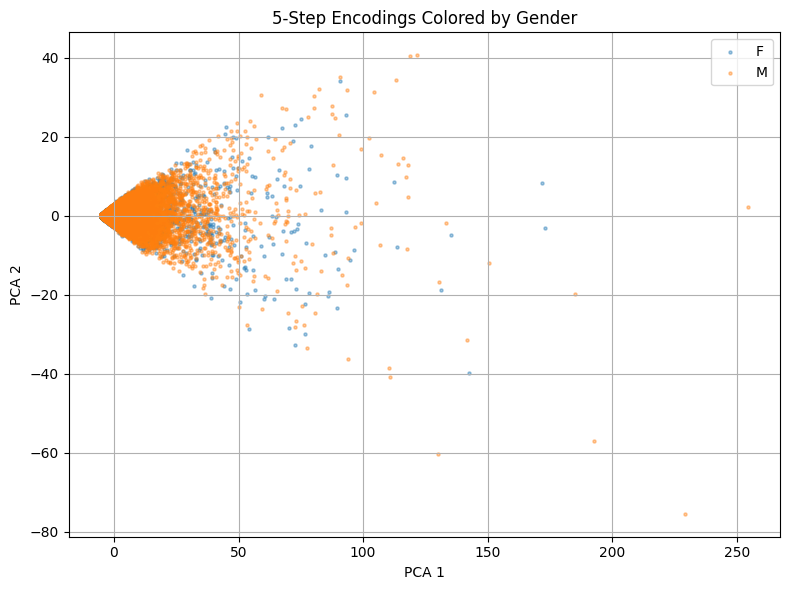

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tensorflow.keras.models import load_model
import joblib
import os

base_path = '../data/kaggle-drdataboston/'

# Load encoded model and scaler
encoder = load_model(os.path.join(base_path, "step_encoder.keras"))
scaler = joblib.load(os.path.join(base_path, "step_scaler.pkl"))

# Load window data and metadata
windows = pd.read_csv(os.path.join(base_path, "all_5step_windows.csv"))
metadata = pd.read_csv(os.path.join(base_path, "5step_metadata.csv"))

# Keep only rows where metadata is valid
valid_idx = ~metadata['gender'].isna()
X = windows.loc[valid_idx, windows.columns[1:101]].values  # exclude filename column
meta = metadata[valid_idx]

# Normalize and encode
X_scaled = scaler.transform(X)
X_encoded = encoder.predict(X_scaled)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_encoded)

# Plot by gender
plt.figure(figsize=(8, 6))
for gender in meta['gender'].unique():
    ix = meta['gender'] == gender
    plt.scatter(X_pca[ix, 0], X_pca[ix, 1], label=gender, alpha=0.4, s=5)

plt.title("5-Step Encodings Colored by Gender")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


2802/2802 ━━━━━━━━━━━━━━━━━━━━ 1s 475us/step


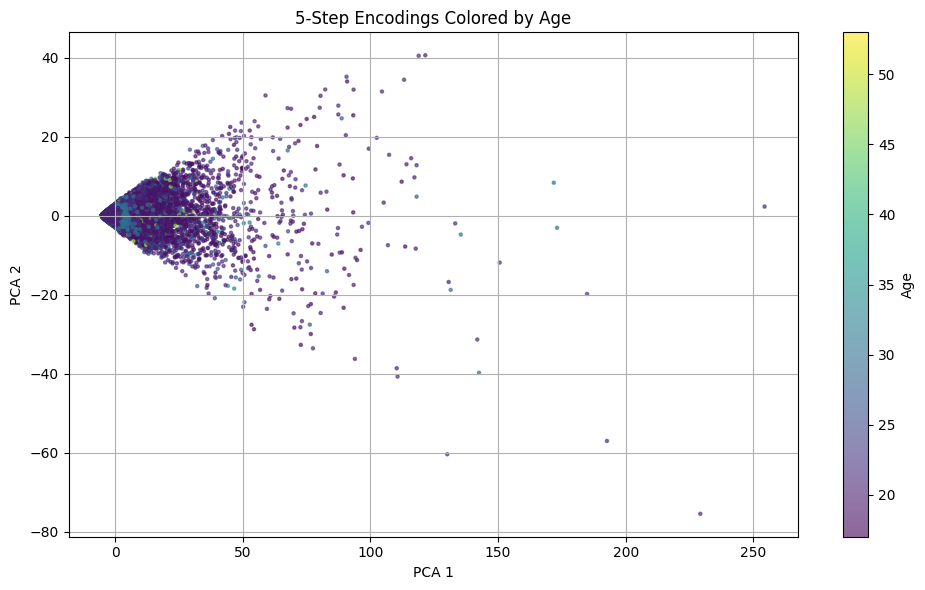

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
import joblib
import os

# Paths
base_path = '../data/kaggle-drdataboston/'
windows = pd.read_csv(os.path.join(base_path, "all_5step_windows.csv"))
metadata = pd.read_csv(os.path.join(base_path, "5step_metadata.csv"))
encoder = load_model(os.path.join(base_path, "step_encoder.keras"))
scaler = joblib.load(os.path.join(base_path, "step_scaler.pkl"))

# Clean
valid_idx = ~metadata['Age'].isna()
X = windows.loc[valid_idx, windows.columns[1:101]].values
meta = metadata.loc[valid_idx]

# Scale and encode
X_scaled = scaler.transform(X)
X_encoded = encoder.predict(X_scaled)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_encoded)

# Plot by age
plt.figure(figsize=(10, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=meta['Age'], cmap='viridis', s=5, alpha=0.6)
plt.colorbar(sc, label='Age')
plt.title("5-Step Encodings Colored by Age")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.tight_layout()
plt.show()


2802/2802 ━━━━━━━━━━━━━━━━━━━━ 1s 412us/step


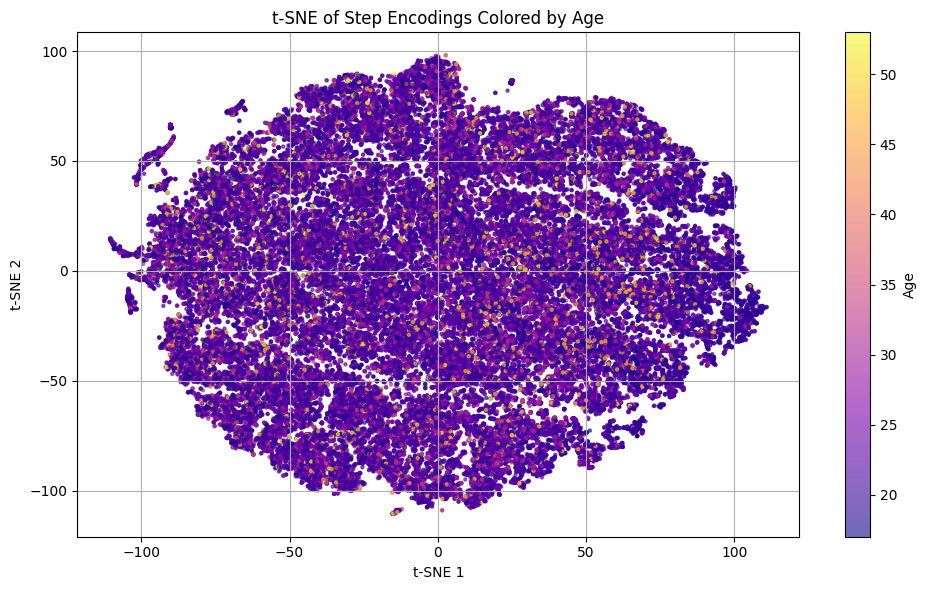

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from tensorflow.keras.models import load_model
import joblib
import os

# Paths
base_path = '../data/kaggle-drdataboston/'
windows = pd.read_csv(os.path.join(base_path, "all_5step_windows.csv"))
metadata = pd.read_csv(os.path.join(base_path, "5step_metadata.csv"))
encoder = load_model(os.path.join(base_path, "step_encoder.keras"))
scaler = joblib.load(os.path.join(base_path, "step_scaler.pkl"))

# Filter out missing age
valid_idx = ~metadata['Age'].isna()
X = windows.loc[valid_idx, windows.columns[1:101]].values
meta = metadata.loc[valid_idx]

# Encode
X_scaled = scaler.transform(X)
X_encoded = encoder.predict(X_scaled)

# Run t-SNE (this might take a minute or two!)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_encoded)

# Plot
plt.figure(figsize=(10, 6))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=meta['Age'], cmap='plasma', s=5, alpha=0.6)
plt.colorbar(sc, label='Age')
plt.title("t-SNE of Step Encodings Colored by Age")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
import numpy as np

np.save('../data/kaggle-drdataboston/X_encoded.npy', X_encoded)
print("✅ Saved X_encoded to X_encoded.npy")


✅ Saved X_encoded to X_encoded.npy


In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, classification_report

# Load encoded features + metadata
base_path = '../data/kaggle-drdataboston/'
X_encoded = np.load(os.path.join(base_path, 'X_encoded.npy'))  # if you saved it as .npy
meta = pd.read_csv(os.path.join(base_path, '5step_metadata.csv'))

# Make sure shape matches
assert len(meta) == len(X_encoded), "Mismatch between features and metadata"

# Filter out rows with missing values in any of the targets
targets = ['Age', 'Weight', 'Height (CM)', 'gender']
meta = meta.dropna(subset=targets)
X = X_encoded[meta.index]

# Encode gender as binary
meta['gender'] = meta['gender'].astype('category')
y_gender = meta['gender'].cat.codes
gender_labels = dict(enumerate(meta['gender'].cat.categories))

# Train-test split
X_train, X_test, y_gender_train, y_gender_test = train_test_split(X, y_gender, test_size=0.2, random_state=42)
_, _, y_age_train, y_age_test = train_test_split(X, meta['Age'], test_size=0.2, random_state=42)
_, _, y_weight_train, y_weight_test = train_test_split(X, meta['Weight'], test_size=0.2, random_state=42)
_, _, y_height_train, y_height_test = train_test_split(X, meta['Height (CM)'], test_size=0.2, random_state=42)

# Gender classification
clf_gender = RandomForestClassifier()
clf_gender.fit(X_train, y_gender_train)
y_pred_gender = clf_gender.predict(X_test)
print("🎯 Gender classification report:")
print(classification_report(y_gender_test, y_pred_gender, target_names=gender_labels.values()))

# Age prediction
reg_age = RandomForestRegressor()
reg_age.fit(X_train, y_age_train)
y_pred_age = reg_age.predict(X_test)
print(f"🎯 Age → R²: {r2_score(y_age_test, y_pred_age):.3f}, MAE: {mean_absolute_error(y_age_test, y_pred_age):.2f}")

# Weight prediction
reg_weight = RandomForestRegressor()
reg_weight.fit(X_train, y_weight_train)
y_pred_weight = reg_weight.predict(X_test)
print(f"🎯 Weight → R²: {r2_score(y_weight_test, y_pred_weight):.3f}, MAE: {mean_absolute_error(y_weight_test, y_pred_weight):.2f}")

# Height prediction
reg_height = RandomForestRegressor()
reg_height.fit(X_train, y_height_train)
y_pred_height = reg_height.predict(X_test)
print(f"🎯 Height → R²: {r2_score(y_height_test, y_pred_height):.3f}, MAE: {mean_absolute_error(y_height_test, y_pred_height):.2f}")


🎯 Gender classification report:
              precision    recall  f1-score   support

           F       0.54      0.58      0.56      8426
           M       0.60      0.57      0.58      9503

    accuracy                           0.57     17929
   macro avg       0.57      0.57      0.57     17929
weighted avg       0.58      0.57      0.57     17929

🎯 Age → R²: -0.014, MAE: 4.89
🎯 Weight → R²: 0.133, MAE: 12.01
🎯 Height → R²: 0.040, MAE: 7.59


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, callbacks
import os

# Load data
base_path = '../data/kaggle-drdataboston/'
X_encoded = np.load(os.path.join(base_path, 'X_encoded.npy'))
meta = pd.read_csv(os.path.join(base_path, '5step_metadata.csv'))

# Drop rows with any missing target
meta = meta.dropna(subset=['Age', 'Weight', 'Height (CM)', 'gender'])
X = X_encoded[meta.index]

# Encode gender as binary
meta['gender'] = meta['gender'].astype('category')
y_gender = meta['gender'].cat.codes
gender_labels = dict(enumerate(meta['gender'].cat.categories))

# Train-test split
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
y_gender_train, y_gender_test = train_test_split(y_gender, test_size=0.2, random_state=42)
y_age_train, y_age_test = train_test_split(meta['Age'], test_size=0.2, random_state=42)
y_weight_train, y_weight_test = train_test_split(meta['Weight'], test_size=0.2, random_state=42)
y_height_train, y_height_test = train_test_split(meta['Height (CM)'], test_size=0.2, random_state=42)


In [16]:
def build_regression_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)  # regression output
    ])
    model.compile(optimizer='adam', loss='mae', metrics=['mae'])
    return model

def build_classification_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [17]:
es = callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# Gender (Classification)
model_gender = build_classification_model(X.shape[1])
model_gender.fit(X_train, y_gender_train, validation_data=(X_test, y_gender_test),
                 epochs=30, batch_size=128, callbacks=[es])

# Age
model_age = build_regression_model(X.shape[1])
model_age.fit(X_train, y_age_train, validation_data=(X_test, y_age_test),
              epochs=30, batch_size=128, callbacks=[es])

# Weight
model_weight = build_regression_model(X.shape[1])
model_weight.fit(X_train, y_weight_train, validation_data=(X_test, y_weight_test),
                 epochs=30, batch_size=128, callbacks=[es])

# Height
model_height = build_regression_model(X.shape[1])
model_height.fit(X_train, y_height_train, validation_data=(X_test, y_height_test),
                 epochs=30, batch_size=128, callbacks=[es])


Epoch 1/30
561/561 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5298 - loss: 0.6889 - val_accuracy: 0.5776 - val_loss: 0.6822
Epoch 2/30
561/561 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5751 - loss: 0.6773 - val_accuracy: 0.5846 - val_loss: 0.6706
Epoch 3/30
561/561 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5805 - loss: 0.6699 - val_accuracy: 0.5842 - val_loss: 0.6678
Epoch 4/30
561/561 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5868 - loss: 0.6666 - val_accuracy: 0.5834 - val_loss: 0.6679
Epoch 5/30
561/561 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5888 - loss: 0.6624 - val_accuracy: 0.5839 - val_loss: 0.6647
Epoch 6/30
561/561 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5881 - loss: 0.6627 - val_accuracy: 0.5837 - val_loss: 0.6653
Epoch 7/30
561/561 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5873 - loss: 0.6642 - val_accuracy: 0.5873 - val_loss: 0.6643
Epoch 8/30
561/561 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5871 - loss: 0.6615 - val_accuracy: 0.

In [ ]:


# Predict & evaluate
from sklearn.metrics import r2_score, mean_absolute_error

y_age_pred = model_age.predict(X_test).flatten()
print(f"Age → R²: {r2_score(y_age_test, y_age_pred):.3f}, MAE: {mean_absolute_error(y_age_test, y_age_pred):.2f}")

y_weight_pred = model_weight.predict(X_test).flatten()
print(f"Weight → R²: {r2_score(y_weight_test, y_weight_pred):.3f}, MAE: {mean_absolute_error(y_weight_test, y_weight_pred):.2f}")

y_height_pred = model_height.predict(X_test).flatten()
print(f"Height → R²: {r2_score(y_height_test, y_height_pred):.3f}, MAE: {mean_absolute_error(y_height_test, y_height_pred):.2f}")

y_gender_pred = model_gender.predict(X_test).flatten() > 0.5
from sklearn.metrics import classification_report
print(classification_report(y_gender_test, y_gender_pred, target_names=gender_labels.values()))


561/561 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step
Age → R²: -0.104, MAE: 4.35
561/561 ━━━━━━━━━━━━━━━━━━━━ 0s 412us/step
Weight → R²: 0.101, MAE: 12.06
561/561 ━━━━━━━━━━━━━━━━━━━━ 0s 398us/step
Height → R²: 0.023, MAE: 7.55
561/561 ━━━━━━━━━━━━━━━━━━━━ 0s 310us/step
              precision    recall  f1-score   support

           F       0.56      0.59      0.57      8426
           M       0.62      0.59      0.60      9503

    accuracy                           0.59     17929
   macro avg       0.59      0.59      0.59     17929
weighted avg       0.59      0.59      0.59     17929



In [15]:
print(meta['gender'].value_counts(normalize=True))


gender
M    0.527878
F    0.472122
Name: proportion, dtype: float64
